## Setup & Imports

In [1]:
import os
import json
import shutil
import numpy as np
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO
import cv2
import random
import matplotlib.pyplot as plt

# --- Configuration ---
PROJECT_ROOT = Path().cwd().parents[1]
DATA_ROOT = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"

# Paths for the NEW Dataset (Dataset 2)
NEW_DATA_DIR = DATA_ROOT / "pseudo_labels" / "train"
NEW_IMAGES_DIR = NEW_DATA_DIR / "images"
ORIGINAL_JSON_PATH = NEW_DATA_DIR / "_annotations.coco.json"

# Output Paths
HYBRID_JSON_PATH = NEW_DATA_DIR / "hybrid_train.json"

# Model Paths
CURRENT_BEST_MODEL = MODELS_DIR / "yolov11m-pose" / "best.pt"
TEMP_MODEL_PATH = EXPERIMENTS_DIR / "models" / "best_pose_v1.pt"

# Ensure directories exist
(EXPERIMENTS_DIR / "models").mkdir(parents=True, exist_ok=True)

print("✅ Setup Complete.")

✅ Setup Complete.


## Define Keypoint Logic (Reused from your results_to_coco.py)

In [2]:
def to_custom_keypoints(yolo_kps):
    """
    Convert YOLO keypoints to Custom 14-keypoint format.
    Handles both 17-point (COCO) and 14-point (Custom) inputs.
    """
    if yolo_kps is None: return [0.0] * 42
    
    # DEBUG: Uncomment this if you still see zeros to check what the model is outputting
    # print(f"Shape: {yolo_kps.shape}") 

    # CASE A: Model output is already 14 keypoints (Pass-through)
    if yolo_kps.shape[0] == 14:
        flat_kps = []
        for kp in yolo_kps:
            x, y, conf = kp
            # Visibility logic: 2=visible (conf>0.5), 1=labeled(conf>0), 0=missing
            v = 2 if conf > 0.5 else (1 if conf > 0 else 0)
            flat_kps.extend([float(x), float(y), int(v)])
        return flat_kps

    # CASE B: Model output is 17 keypoints (COCO -> Custom 14 Conversion)
    if yolo_kps.shape[0] == 17:
        left_shoulder = yolo_kps[5]
        right_shoulder = yolo_kps[6]
        
        # Calculate Neck
        neck_x = (left_shoulder[0] + right_shoulder[0]) / 2.0
        neck_y = (left_shoulder[1] + right_shoulder[1]) / 2.0
        neck_conf = min(left_shoulder[2], right_shoulder[2])
        neck = np.array([neck_x, neck_y, neck_conf])

        # Map to custom 14 order
        custom_kps = [
            yolo_kps[0],     # Nose
            neck,            # Neck
            yolo_kps[5],     # L_Shoulder
            yolo_kps[6],     # R_Shoulder
            yolo_kps[7],     # L_Elbow
            yolo_kps[8],     # R_Elbow
            yolo_kps[9],     # L_Wrist
            yolo_kps[10],    # R_Wrist
            yolo_kps[11],    # L_Hip
            yolo_kps[12],    # R_Hip
            yolo_kps[13],    # L_Knee
            yolo_kps[14],    # R_Knee
            yolo_kps[15],    # L_Ankle
            yolo_kps[16]     # R_Ankle
        ]
        
        flat_kps = []
        for kp in custom_kps:
            x, y, conf = kp
            v = 2 if conf > 0.5 else (1 if conf > 0 else 0)
            flat_kps.extend([float(x), float(y), int(v)])
        return flat_kps
        
    # Fallback
    return [0.0] * 42

def calculate_iou(boxA, boxB):
    # Standard IoU
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0]+boxA[2], boxB[0]+boxB[2])
    yB = min(boxA[1]+boxA[3], boxB[1]+boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

## Load and Fix Annotations (Memory)

In [3]:
print("🔧 Loading and patching Dataset 2 Annotations...")

with open(ORIGINAL_JSON_PATH, 'r') as f:
    coco_data = json.load(f)

# A. Fix Categories (Inject your Keypoints/Skeleton)
# Also fix the Class IDs (Red 2->1, Blue 1->2)
dataset_categories = [
    {
        "id": 1, 
        "name": "boxer_red", 
        "supercategory": "person",
        "keypoints": ["left_shoulder", "right_shoulder", "left_hip", "right_hip", 
                      "left_knee", "right_knee", "left_ankle", "right_ankle", 
                      "left_elbow", "left_wrist", "right_elbow", "right_wrist", 
                      "neck", "nose"],
        "skeleton": [[9, 10], [1, 3], [2, 4], [1, 2], [3, 4], [6, 8], [4, 6], 
                     [5, 7], [11, 12], [14, 13], [1, 13], [13, 2], [2, 11], [1, 9], [3, 5]]
    },
    {
        "id": 2, 
        "name": "boxer_blue", 
        "supercategory": "person",
        "keypoints": ["left_shoulder", "right_shoulder", "left_hip", "right_hip", 
                      "left_knee", "right_knee", "left_ankle", "right_ankle", 
                      "left_elbow", "left_wrist", "right_elbow", "right_wrist", 
                      "neck", "nose"],
        "skeleton": [[9, 10], [1, 3], [2, 4], [1, 2], [3, 4], [6, 8], [4, 6], 
                     [5, 7], [11, 12], [14, 13], [1, 13], [13, 2], [2, 11], [1, 9], [3, 5]]
    }
]
coco_data['categories'] = dataset_categories

# B. Create Lookup Maps
# Map: filename -> image_id
filename_to_id = {img['file_name']: img['id'] for img in coco_data['images']}
# Map: image_id -> List[Annotations]
gt_map = {}
class_fix_map = {1: 2, 2: 1} # Old->New

for ann in coco_data['annotations']:
    # FIX: Swap Class IDs here
    old_cat = ann['category_id']
    if old_cat in class_fix_map:
        ann['category_id'] = class_fix_map[old_cat]
        
    img_id = ann['image_id']
    if img_id not in gt_map: gt_map[img_id] = []
    gt_map[img_id].append(ann)

print("✅ Categories patched & Class IDs swapped.")

🔧 Loading and patching Dataset 2 Annotations...
✅ Categories patched & Class IDs swapped.


## Streaming Inference & Hybrid Merge

In [4]:
# We will rebuild 'coco_data["annotations"]' from scratch using the hybrid logic.
hybrid_annotations = []
new_ann_id = 1

# Setup Model
shutil.copy2(CURRENT_BEST_MODEL, TEMP_MODEL_PATH)
model = YOLO(TEMP_MODEL_PATH)

print("🚀 Starting Streaming Inference + Hybrid Merge...")

# Create Generator (Stream=True is critical for RAM)
results_generator = model.predict(
    source=str(NEW_IMAGES_DIR),
    stream=True,      # <--- THE FIX: Process batches one by one
    conf=0.1,
    iou=0.45,
    max_det=10,
    device=0,         # Force GPU
    batch=16,         # Keep batch size moderate
    verbose=False
)

for result in tqdm(results_generator, total=len(filename_to_id)):
    # 1. Identify Image
    # Result path might be absolute, we need just the filename
    fname = Path(result.path).name 
    if fname not in filename_to_id:
        continue # Should not happen if folder matches JSON
        
    img_id = filename_to_id[fname]
    
    # 2. Get Ground Truth for this image
    gt_anns = gt_map.get(img_id, [])
    if not gt_anns:
        continue

    # 3. Get Model Predictions
    # result.boxes.xyxy (N, 4)
    # result.keypoints.data (N, 17, 3)
    pred_boxes = result.boxes.xyxy.cpu().numpy() if result.boxes else []
    pred_kpts = result.keypoints.data.cpu().numpy() if result.keypoints else []
    
    # 4. The Merge Loop
    for gt in gt_anns:
        gt_box = gt['bbox'] # [x, y, w, h]
        
        best_iou = 0
        best_kpts_raw = None
        
        # Match GT Box to a Predicted Box
        for i, p_box in enumerate(pred_boxes):
            # p_box is [x1, y1, x2, y2]. Convert to xywh for IoU
            p_box_xywh = [p_box[0], p_box[1], p_box[2]-p_box[0], p_box[3]-p_box[1]]
            
            iou = calculate_iou(gt_box, p_box_xywh)
            if iou > best_iou:
                best_iou = iou
                best_kpts_raw = pred_kpts[i] # (17, 3)

        # 5. Hybrid Decision
        final_kpts = []
        
        if best_iou > 0.5 and best_kpts_raw is not None:
            # HIT: Use Pred Keypoints (Converted to 14 format)
            # print(f"Match Found! Model output shape: {best_kpts_raw.shape}")
            final_kpts = to_custom_keypoints(best_kpts_raw)
        else:
            # MISS: Use Zeros (Masked)
            final_kpts = [0.0] * 42 # 14 points * 3

        # 6. Create New Annotation
        new_ann = {
            "id": new_ann_id,
            "image_id": img_id,
            "category_id": gt['category_id'], # Trusted GT Class
            "bbox": gt['bbox'],               # Trusted GT Box
            "area": gt['area'],
            "iscrowd": gt['iscrowd'],
            "num_keypoints": 14,              # Always 14 now
            "keypoints": final_kpts,
            "segmentation": []
        }
        hybrid_annotations.append(new_ann)
        new_ann_id += 1

🚀 Starting Streaming Inference + Hybrid Merge...


100%|██████████| 913/913 [00:10<00:00, 87.59it/s] 


## Save Final JSON

In [5]:
print(f"📝 Finalizing JSON with {len(hybrid_annotations)} annotations...")

# Replace annotations in the COCO dict
coco_data['annotations'] = hybrid_annotations

with open(HYBRID_JSON_PATH, 'w') as f:
    json.dump(coco_data, f)

print("="*40)
print(f"✅ DONE! Hybrid Dataset saved to: {HYBRID_JSON_PATH}")
print("You can now point your training pipeline to this JSON file.")
print("="*40)

📝 Finalizing JSON with 1716 annotations...
✅ DONE! Hybrid Dataset saved to: /home/cooper/Desktop/My Personal/Repositories/Boxer-Pose-Estimation/data/pseudo_labels/train/hybrid_train.json
You can now point your training pipeline to this JSON file.


## Sample Visualization

🔍 Inspecting Hybrid JSON: /home/cooper/Desktop/My Personal/Repositories/Boxer-Pose-Estimation/data/pseudo_labels/train/hybrid_train.json


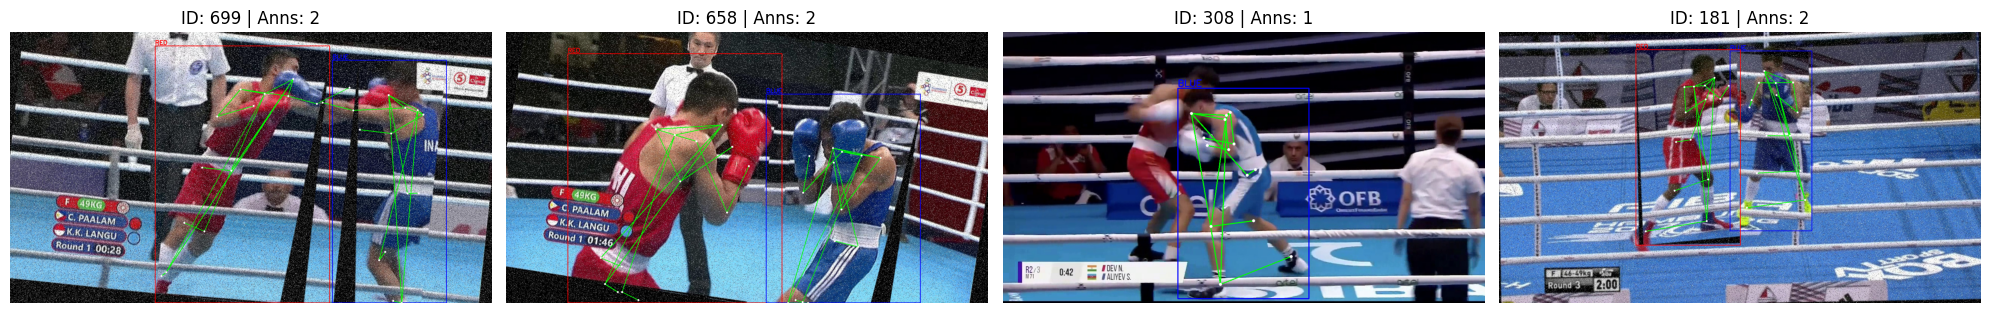

In [6]:
# --- Config from your visualize.py ---
# Colors (BGR in cv2, so we'll convert to RGB for matplotlib later)
COLORS = {
    1: (0, 0, 255),    # Red (Boxer Red)
    2: (255, 0, 0),    # Blue (Boxer Blue)
    'skeleton': (0, 255, 0)
}

SKELETON_CONNECTIONS = [
    (8, 9), (0, 2), (1, 3), (0, 1), (2, 3), (5, 7), (3, 5), (4, 6),
    (10, 11), (13, 12), (0, 12), (12, 1), (1, 10), (0, 8), (2, 4)
]

def draw_annotation(img, ann):
    """Overlay bbox and keypoints on the image."""
    cat_id = ann['category_id']
    bbox = ann['bbox'] # x, y, w, h
    kpts = ann['keypoints']
    
    # 1. Draw BBox
    x, y, w, h = map(int, bbox)
    color = COLORS.get(cat_id, (128, 128, 128))
    cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
    
    # Label
    label = "RED" if cat_id == 1 else "BLUE"
    cv2.putText(img, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # 2. Parse Keypoints (x, y, vis)
    # kpts list is flat [x1, y1, v1, x2, y2, v2...]
    points = []
    for i in range(0, len(kpts), 3):
        kx, ky, v = kpts[i], kpts[i+1], kpts[i+2]
        if v > 0: # Visible or Occluded
            points.append((int(kx), int(ky)))
        else:
            points.append(None) # Missing/Masked

    # 3. Draw Skeleton
    for i1, i2 in SKELETON_CONNECTIONS:
        if i1 < len(points) and i2 < len(points):
            p1, p2 = points[i1], points[i2]
            if p1 and p2:
                cv2.line(img, p1, p2, COLORS['skeleton'], 2)

    # 4. Draw Points
    for p in points:
        if p:
            cv2.circle(img, p, 4, (255, 255, 255), -1) # White dots
            
    return img

# --- Execution ---
print(f"🔍 Inspecting Hybrid JSON: {HYBRID_JSON_PATH}")

with open(HYBRID_JSON_PATH, 'r') as f:
    data = json.load(f)

# Group anns by image_id
img_anns = {}
for ann in data['annotations']:
    img_anns.setdefault(ann['image_id'], []).append(ann)

# Sample random images
sample_ids = random.sample(list(data['images']), 4)

plt.figure(figsize=(20, 10))

for i, img_info in enumerate(sample_ids):
    img_id = img_info['id']
    
    # Resolve Path (Handle absolute vs relative)
    # Try absolute first, then join with dir
    fname = img_info['file_name']
    if os.path.exists(fname):
        img_path = fname
    else:
        # Fallback to name inside NEW_IMAGES_DIR
        img_path = NEW_IMAGES_DIR / Path(fname).name
        
    if not os.path.exists(img_path):
        print(f"⚠️ Missing Image: {img_path}")
        continue
        
    # Load Image
    img = cv2.imread(str(img_path))
    if img is None: continue
    
    # Draw
    anns = img_anns.get(img_id, [])
    for ann in anns:
        img = draw_annotation(img, ann)
        
    # Convert BGR (OpenCV) -> RGB (Matplotlib)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"ID: {img_id} | Anns: {len(anns)}")

plt.tight_layout()
plt.show()